# Stage 09 Characterization Probability Verification

This notebook documents and verifies the completed Stage 09 characterization-probability map:

- `cache/09_characterization_probability_v1.h5`
- `cache/09_characterization_probability_summary.json`
- `cache/09_characterization_probability_smoke_summary.json`

The production Stage 09 artifact consumes the production Stage 08 grid, not the Stage 08 pilot or smoke artifacts.

## What Stage 09 Does

Stage 09 converts the per-temperature detection grid `p_det(T, tau, A)` into a multi-temperature characterization probability:

`P(characterized | tau_135, E)`

For each point on the final `(tau_135, E)` grid, the stage:

1. Infers `log_sigma` from `tau_135` and `E` using `dipole.log_energy_cross_section`.
2. Computes the implied `tau(T)` at all measured Stage 08 temperatures.
3. Interpolates Stage 08 `p_det(T, tau, A)` over `log(tau)` and linear amplitude.
4. Reconstructs amplitudes as `A(T) = D_t * P_c(T)` using the Stage 05 default depth prior.
5. Marginalizes the Poisson-binomial `P(sum detections >= n_good)` over the empirical Stage 05 depth samples.
6. Saves the primary `n_good = 4` map and an `n_good = 3` sensitivity map.

Important interpretation note: the Stage 05 default amplitude prior is conditional on observed high-confidence traps. It is not a faint-trap population model.

## Expected Production Outputs

A healthy production run should have:

- Map shape: `161 x 121` for `(tau_135, E)`.
- `tau_135` range: `1e-4` to `1e8 s`, log-spaced.
- `E` range: `0.04` to `0.70 eV`, linearly spaced.
- Stage 08 input shape: `23 T x 55 tau x 35 A`.
- Stage 05 default prior depth samples: `2135`.
- Poisson-binomial brute-force validation: `PASS`.
- `tau_135` algebra reconstruction check: `PASS`.
- Known `n_good = 4` traps: most should have high `P_4`; production result has `99.86%` with `P_4 >= 0.8`.
- Known `n_good = 3` traps: most should have high `P_3`; production result has `99.96%` with `P_3 >= 0.8`.
- Default-prior amplitude below-grid and above-grid fractions: both `0.0`.
- A clearly flagged all-temperatures-out-of-Stage-08-tau-band regime where `P_4 = 0` under the explicit no-extrapolation policy.

In [2]:
from pathlib import Path
import json

import h5py
import numpy as np


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "trap_completeness_method3" / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find repo root from current working directory")


repo = find_repo_root()
workspace = repo / "trap_completeness_method3"
cache = workspace / "cache"

h5_path = cache / "09_characterization_probability_v1.h5"
summary_path = cache / "09_characterization_probability_summary.json"
smoke_summary_path = cache / "09_characterization_probability_smoke_summary.json"
stage08_h5_path = cache / "08_pdet_grid_v1.h5"
stage05_npz_path = cache / "05_amplitude_prior_v1.npz"

paths = [h5_path, summary_path, smoke_summary_path, stage08_h5_path, stage05_npz_path]
for path in paths:
    print(path.relative_to(repo), path.exists(), f"{path.stat().st_size / 1024:.1f} KiB" if path.exists() else "missing")
    assert path.exists()

trap_completeness_method3\cache\09_characterization_probability_v1.h5 True 926.7 KiB
trap_completeness_method3\cache\09_characterization_probability_summary.json True 56.2 KiB
trap_completeness_method3\cache\09_characterization_probability_smoke_summary.json True 23.4 KiB
trap_completeness_method3\cache\08_pdet_grid_v1.h5 True 1045.8 KiB
trap_completeness_method3\cache\05_amplitude_prior_v1.npz True 168.9 KiB


## Load Summary Metadata

The summary JSON is the most compact place to start. It stores input provenance, grid definitions, interpolation policy, validation status, and headline numbers.

In [3]:
with summary_path.open("r", encoding="utf-8") as handle:
    summary = json.load(handle)

with smoke_summary_path.open("r", encoding="utf-8") as handle:
    smoke = json.load(handle)

for key in ["producing_stage", "produced_at", "code_path", "runtime_seconds"]:
    print(f"{key}: {summary[key]}")

print("\nOutputs:")
print(json.dumps(summary["outputs"], indent=2))

print("\nStage 08 provenance:")
for key in ["producing_stage", "produced_at", "random_seed", "realizations_per_grid_point", "shape"]:
    print(f"{key}: {summary['stage08_production_provenance'][key]}")

producing_stage: 09_characterization_probability
produced_at: 2026-05-23T11:00:34-07:00
code_path: /mnt/c/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/src/characterization_probability.py
runtime_seconds: 30.906800790005946

Outputs:
{
  "hdf5": "/mnt/c/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/cache/09_characterization_probability_v1.h5",
  "summary_json": "/mnt/c/Users/Ansh/Projects/sensei_charge_traps/trap_completeness_method3/cache/09_characterization_probability_summary.json"
}

Stage 08 provenance:
producing_stage: 08_full_pdet_grid
produced_at: 2026-05-22T13:01:13-07:00
random_seed: 2026052209
realizations_per_grid_point: 100
shape: {'amplitude_count': 35, 'fits_main_grid': 4427500, 'grid_points': 44275, 'max_delay_count': 25, 'tau_count': 55, 'temperature_count': 23}


## Verify HDF5 Structure

The HDF5 should contain the final grids, both probability maps, diagnostics, the aligned amplitude prior, and validation arrays for both Stage 01 characterized-trap CSVs.

In [4]:
with h5py.File(h5_path, "r") as h5:
    print("top-level groups:", list(h5.keys()))
    print("result datasets:", list(h5["results"].keys()))
    print("diagnostic datasets:", list(h5["diagnostics"].keys()))
    print("validation groups:", list(h5["validation_known_traps"].keys()))

    tau_135 = h5["grid/tau_135_seconds"][:]
    energy = h5["grid/E_eV"][:]
    temperatures = h5["grid/temperature_K"][:]
    stage08_tau = h5["grid/stage08_tau_seconds"][:]
    stage08_amp = h5["grid/stage08_amplitude_electrons"][:]
    p4 = h5["results/p_characterized_n_good_4"][:]
    p3 = h5["results/p_characterized_n_good_3"][:]
    tau_oob_fraction = h5["diagnostics/tau_oob_fraction"][:]
    all_temperatures_tau_oob = h5["diagnostics/all_temperatures_tau_oob"][:].astype(bool)
    depth_samples = h5["amplitude_prior/depth_electrons_at_pc135"][:]
    pc_factor = h5["amplitude_prior/pc_temperature_factor_aligned_to_stage08"][:]
    known_p4 = h5["validation_known_traps/n_good_4_csv/p_characterized_n_good_4"][:]
    known_p3 = h5["validation_known_traps/n_good_3_csv/p_characterized_n_good_3"][:]

print("p4 shape:", p4.shape)
print("p3 shape:", p3.shape)
print("tau_135 range/count:", tau_135[0], tau_135[-1], len(tau_135))
print("E range/count:", energy[0], energy[-1], len(energy))
print("Stage 08 tau range/count:", stage08_tau[0], stage08_tau[-1], len(stage08_tau))
print("Stage 08 amplitude range/count:", stage08_amp[0], stage08_amp[-1], len(stage08_amp))

assert p4.shape == (161, 121)
assert p3.shape == (161, 121)
assert len(temperatures) == 23
assert len(stage08_tau) == 55
assert len(stage08_amp) == 35
assert len(depth_samples) == 2135
assert known_p4.shape == (2135,)
assert known_p3.shape == (2517,)
print("HDF5 structure matches Stage 09 expectations.")

top-level groups: ['amplitude_prior', 'diagnostics', 'grid', 'results', 'validation_known_traps']
result datasets: ['p_characterized_n_good_3', 'p_characterized_n_good_4']
diagnostic datasets: ['all_temperatures_tau_oob', 'amplitude_above_count_by_temperature', 'amplitude_below_count_by_temperature', 'tau_oob_count', 'tau_oob_fraction']
validation groups: ['n_good_3_csv', 'n_good_4_csv']
p4 shape: (161, 121)
p3 shape: (161, 121)
tau_135 range/count: 0.0001 100000000.0 161
E range/count: 0.04 0.7 121
Stage 08 tau range/count: 2e-05 20.0 55
Stage 08 amplitude range/count: 200.0 15000.0 35
HDF5 structure matches Stage 09 expectations.


## Verify Required Checks

These checks are hard gates. If either assertion fails, the Stage 09 artifact should not be used downstream.

In [5]:
algebra = summary["algebra_check"]
poisson = summary["poisson_binomial_tests"]

print("algebra check:", algebra)
print("poisson max_abs_error:", poisson["max_abs_error"])

assert algebra["passed"]
assert algebra["max_abs_log_tau_error"] < 1e-12
assert poisson["passed"]
assert poisson["max_abs_error"] < 1e-12
print("Required mathematical checks passed.")

algebra check: {'formula': 'log_sigma = log_energy_cross_section(135, E, 0) - log(tau_135)', 'max_abs_log_tau_error': 7.105427357601002e-15, 'median_abs_log_tau_error': 1.7763568394002505e-15, 'passed': True}
poisson max_abs_error: 1.3877787807814457e-16
Required mathematical checks passed.


## Interpolation And Out-Of-Grid Policy

Stage 09 deliberately avoids silent extrapolation over important regions:

- Interpolate over `log(tau)` and linear amplitude.
- Use exact measured temperatures; do not interpolate in temperature.
- Set temperature-level detection probability to zero when implied `tau(T)` is outside the Stage 08 tau grid.
- Set amplitudes below the Stage 08 amplitude grid to zero.
- Edge-clip amplitudes above the Stage 08 amplitude grid.

For the default Stage 05 prior, no amplitudes are actually below or above the Stage 08 amplitude grid.

In [6]:
print(json.dumps(summary["interpolation_policy"], indent=2, sort_keys=True))
print("\nOut-of-range summary:")
for key, value in summary["interpolation_out_of_range"].items():
    if key != "per_temperature":
        print(f"{key}: {value}")

assert summary["interpolation_out_of_range"]["amplitude_below_grid_fraction"] == 0.0
assert summary["interpolation_out_of_range"]["amplitude_above_grid_fraction"] == 0.0
assert summary["interpolation_out_of_range"]["tau_out_of_grid_fraction"] > 0.0
print("Out-of-grid handling is explicit and recorded.")

{
  "amplitude_above_grid": "edge_clipped",
  "amplitude_axis": "linear_electrons",
  "amplitude_below_grid": "zero",
  "tau_above_grid": "zero",
  "tau_axis": "log_tau_seconds",
  "tau_below_grid": "zero",
  "temperature_axis": "exact_measured_temperatures_only"
}

Out-of-range summary:
all_temperatures_tau_out_of_grid_fraction: 0.16133668702838663
amplitude_above_grid_fraction: 0.0
amplitude_below_grid_fraction: 0.0
depth_sample_count: 2135
pdet_queries_edge_clipped_by_amplitude_above_fraction: 0.0
pdet_queries_zeroed_by_amplitude_below_fraction: 0.0
pdet_queries_zeroed_by_tau_fraction: 0.5256827722887183
point_count: 19481
tau_above_grid_fraction: 0.32021389849195314
tau_below_grid_fraction: 0.20546887379676518
tau_out_of_grid_fraction: 0.5256827722887183
temperature_count: 23
Out-of-grid handling is explicit and recorded.


## Probability Map Summary

The broad production map intentionally includes regions far outside the observed characterized-trap population. The median is high because much of the grid lies in easy-to-characterize regions, while the lower tail is exactly zero in out-of-band regions where Stage 08 provides no tau support.

In [7]:
for key in ["probability_summary_n_good_4", "probability_summary_n_good_3"]:
    print("\n" + key)
    print(json.dumps(summary[key], indent=2, sort_keys=True))

assert np.all((p4 >= 0.0) & (p4 <= 1.0))
assert np.all((p3 >= 0.0) & (p3 <= 1.0))
assert np.nanmedian(p4) > 0.99
assert np.nanmedian(p3) > 0.99


probability_summary_n_good_4
{
  "count": 19481,
  "finite_count": 19481,
  "fraction_ge_0p5": 0.7468302448539603,
  "fraction_ge_0p8": 0.7107438016528925,
  "fraction_ge_0p9": 0.6844617832760125,
  "max": 0.9999999999903679,
  "mean": 0.7347897736196607,
  "median": 0.9978735282062214,
  "min": 0.0,
  "p01": 0.0,
  "p05": 0.0,
  "p16": 0.0,
  "p84": 0.9999993373688033,
  "p95": 0.9999999926487967,
  "p99": 0.9999999998134838
}

probability_summary_n_good_3
{
  "count": 19481,
  "finite_count": 19481,
  "fraction_ge_0p5": 0.7802987526307684,
  "fraction_ge_0p8": 0.7674657358451825,
  "fraction_ge_0p9": 0.7412863816025871,
  "max": 0.999999999999516,
  "mean": 0.7731119940366573,
  "median": 0.9996476005368964,
  "min": 0.0,
  "p01": 0.0,
  "p05": 0.0,
  "p16": 0.0,
  "p84": 0.9999999417725316,
  "p95": 0.9999999994461729,
  "p99": 0.9999999999881233
}


## Known-Trap Validation

This is the main human sanity check. Characterized traps from Stage 01 should mostly land in high-probability regions. A small number of edge cases can be low when their fitted parameters imply many temperatures outside the Stage 08 tau grid.

In [8]:
validation = summary["known_trap_validation"]
ng4 = validation["n_good_4_csv"]
ng3 = validation["n_good_3_csv"]

print("n_good=4 CSV:")
print(json.dumps(ng4["n_good_4_probability"], indent=2, sort_keys=True))
print("\nn_good=3 CSV:")
print(json.dumps(ng3["n_good_3_probability"], indent=2, sort_keys=True))

assert ng4["trap_count"] == 2135
assert ng4["fraction_p4_ge_0p8"] > 0.99
assert ng4["low_p4_count_lt_0p5"] == 1
assert ng3["trap_count"] == 2517
assert ng3["n_good_3_probability"]["fraction_ge_0p8"] > 0.99
print("Known-trap validation matches expectations.")

n_good=4 CSV:
{
  "count": 2135,
  "finite_count": 2135,
  "fraction_ge_0p5": 0.9995316159250586,
  "fraction_ge_0p8": 0.9985948477751756,
  "fraction_ge_0p9": 0.9985948477751756,
  "max": 0.9999999997601068,
  "mean": 0.9990909437603792,
  "median": 0.999999961289453,
  "min": 0.014516909503459212,
  "p01": 0.9985117603851804,
  "p05": 0.999999572999425,
  "p16": 0.9999999271200183,
  "p84": 0.999999985950261,
  "p95": 0.9999999959878877,
  "p99": 0.9999999990819621
}

n_good=3 CSV:
{
  "count": 2517,
  "finite_count": 2517,
  "fraction_ge_0p5": 0.9996027016289233,
  "fraction_ge_0p8": 0.9996027016289233,
  "fraction_ge_0p9": 0.9996027016289233,
  "max": 0.9999999999856322,
  "mean": 0.9995507310079971,
  "median": 0.999999996631936,
  "min": 0.10625157270561578,
  "p01": 0.9998049517392333,
  "p05": 0.9999999476112722,
  "p16": 0.9999999914563713,
  "p84": 0.9999999989578457,
  "p95": 0.9999999997391584,
  "p99": 0.9999999999470757
}
Known-trap validation matches expectations.


## All-Temperatures-Out-Of-Band Regime

This regime is not a numerical failure. It is the explicitly flagged part of `(tau_135, E)` space where every measured temperature maps outside the Stage 08 tau grid. Under the primary no-extrapolation policy, `P_4` is exactly zero there.

In [9]:
unbounded = summary["all_temperatures_out_of_band_regime"]
print(json.dumps(unbounded, indent=2, sort_keys=True))

assert unbounded["all_temperatures_out_of_band_grid_fraction"] > 0.0
assert unbounded["max_p4_when_all_temperatures_out_of_band"] == 0.0
assert np.all(p4[all_temperatures_tau_oob] == 0.0)
print("All-temperatures-out-of-band regime is flagged and bounded by policy.")

{
  "all_temperatures_out_of_band_grid_fraction": 0.16133668702838663,
  "all_temperatures_out_of_stage08_tau_band": {
    "E_eV_max": 0.4745,
    "E_eV_min": 0.04,
    "count": 3143,
    "p4_max": 0.0,
    "p4_median": 0.0,
    "p4_min": 0.0,
    "tau_135_seconds_max": 100000000.0,
    "tau_135_seconds_min": 167.88040181225588
  },
  "definition": "Regimes are flagged by the fraction of measured temperatures whose implied tau(T) is outside the Stage 08 tau grid. Under the Stage 09 primary policy, those temperature detections are set to zero rather than extrapolated.",
  "max_p4_when_all_temperatures_out_of_band": 0.0,
  "tau_oob_fraction_ge_0p8_and_p4_lt_0p1": {
    "E_eV_max": 0.7,
    "E_eV_min": 0.04,
    "count": 3987,
    "p4_max": 0.09923917051226917,
    "p4_median": 0.0,
    "p4_min": 0.0,
    "tau_135_seconds_max": 100000000.0,
    "tau_135_seconds_min": 0.0001
  }
}
All-temperatures-out-of-band regime is flagged and bounded by policy.


## Quick-Look Figures

The cached PNGs are convenience products. The plots below redraw the same essential views from HDF5 for interactive review.

ValueError: Passing a Normalize instance simultaneously with vmin/vmax is not supported.  Please pass vmin/vmax directly to the norm when creating it.

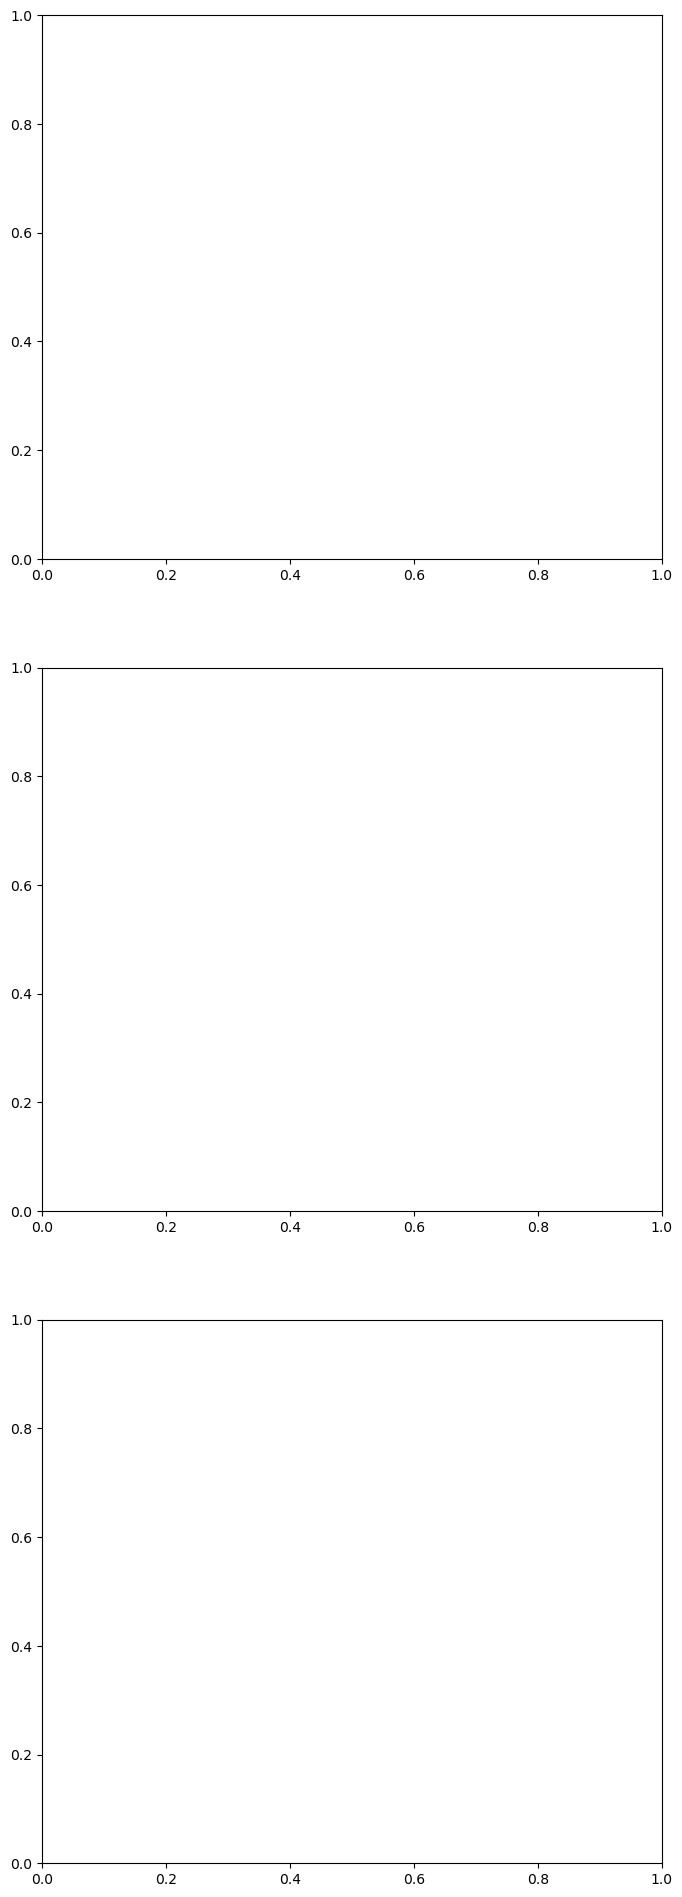

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors

fig, axes = plt.subplots(3, 1, figsize=(8, 24), sharey=True)
for ax, data, title, cmap in [
    (axes[0], p4, "P(characterized), n_good=4", "viridis"),
    (axes[1], p3, "P(characterized), n_good=3", "viridis"),
    (axes[2], tau_oob_fraction, "Tau out-of-band fraction", "magma"),
]:
    mesh = ax.pcolormesh(tau_135, energy, data.T, shading="auto", vmin=0.0, vmax=1.0, cmap=cmap,norm=colors.LogNorm(vmin=0.00001,vmax=1))
    ax.set_xscale("log")
    ax.set_xlabel("tau_135 [s]")
    ax.set_title(title)
    fig.colorbar(mesh, ax=ax)
axes[0].set_ylabel("E [eV]")
fig.tight_layout()

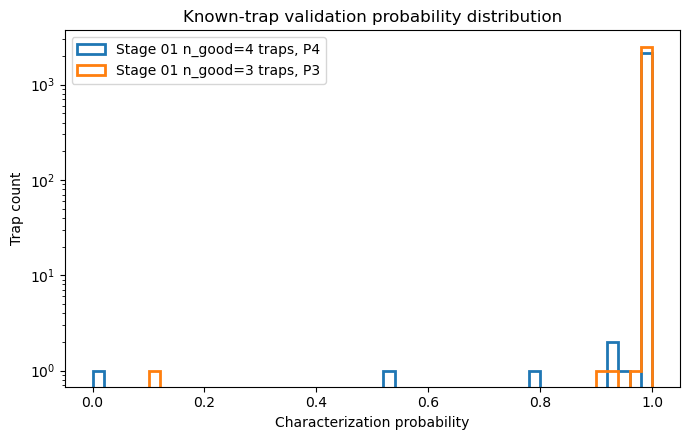

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 1, 51)
ax.hist(known_p4, bins=bins, histtype="step", linewidth=2, label="Stage 01 n_good=4 traps, P4")
ax.hist(known_p3, bins=bins, histtype="step", linewidth=2, label="Stage 01 n_good=3 traps, P3")
ax.set_xlabel("Characterization probability")
ax.set_ylabel("Trap count")
ax.set_yscale("log")
ax.legend()
ax.set_title("Known-trap validation probability distribution")
fig.tight_layout()

## Human Review Checklist

Before handing this artifact to Stage 10, verify:

- The notebook is loading `cache/09_characterization_probability_v1.h5` and `cache/09_characterization_probability_summary.json`.
- Stage 08 provenance points to `cache/08_pdet_grid_v1.h5`, not pilot artifacts.
- The amplitude prior variant is `default`, with the conditional-prior caveat preserved.
- The interpolation policy is acceptable for Stage 10: tau out-of-grid values are zeroed, amplitude below-grid values are zeroed, amplitude above-grid values are edge-clipped.
- Known-trap validation is high except for documented edge cases.
- The all-temperatures-out-of-band region is treated as genuinely unbounded by Stage 08 support, not as a smooth extrapolated probability.